In [ ]:
'''
Data Description :
This project aims to develop an automated classification system that 
recognize and categorize different species of flowers using deep learning techniques.
We utilized the MobileNetV2 architecture and applied Transfer Learning to achieve high accuracy with a relatively small dataset.
By leveraging the pre-trained weights of a model trained on millions of images, we developed a system capable of identifying flower types with high precision.

Methodology & Process
The model was trained and evaluated using the "Flowers Recognition" dataset sourced from Kaggle.
Data Source: Kaggle - Flowers Recognition Dataset
Total Images: Approximately 4,317 color images.
Classes: 5 distinct flower categories (Daisy, Dandelion, Rose, Sunflower, and Tulip).
Dataset Characteristics: The images feature various angles, lighting conditions, and backgrounds, which helps improve the model's robustness in real-world scenarios.

'''


In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# For visualization
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = 'flowers' 
IMG_SIZE = 224 

def load_data():
    images = []
    labels = []
    
    # Checking if folder exists
    if not os.path.exists(DATA_DIR):
        print(f"Error: '{DATA_DIR}' folder not found. Please check the folder name.")
        return np.array([]), np.array([])

    # Get only folders (excludes hidden files)
    CLASSES = [f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))]
    
    for label_id, class_name in enumerate(CLASSES):
        class_path = os.path.join(DATA_DIR, class_name)
        print(f"Loading... : {class_name}")
        
        for img_name in tqdm(os.listdir(class_path)):
            try:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                if img is None: continue # Checking for corrupted files
                
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                
                images.append(img)
                labels.append(label_id)
            except Exception:
                continue
                
    return np.array(images), np.array(labels), CLASSES

# Load the data
X, y, class_names = load_data()

if len(X) > 0:
    print(f"\n--- Upload Complete ---")
    print(f"Image Count: {len(X)}")
    print(f"Identified Classes: {class_names}") 

Loading... : daisy


100%|██████████| 764/764 [00:01<00:00, 396.52it/s]


Loading... : dandelion


100%|██████████| 1052/1052 [00:02<00:00, 383.01it/s]


Loading... : rose


...

Loading... : sunflower


100%|██████████| 733/733 [00:02<00:00, 325.74it/s]


Loading... : tulip


100%|██████████| 984/984 [00:02<00:00, 363.26it/s]



--- Upload Complete ---
Image Count: 4317
Identified Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [3]:
num_classes = len(class_names) 

# Load Pre-trained Model
# include_top=False: Excluding the final classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze existing weights (for fast training and success)
base_model.trainable = False

# New Model Architecture
model = models.Sequential([
    # Input layer (Adapting to your 0-1 normalization)
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Lambda(lambda x: (x * 2.0) - 1.0), # [0,1] -> [-1,1] transformation (MobileNet expectation)
    
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # To prevent overfitting
    layers.Dense(num_classes, activation='softmax')
])

# Compilation
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
from sklearn.model_selection import train_test_split

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Normalization: Scaling values from 0-255 to the 0-1 range
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (3453, 224, 224, 3)
Test set size: (864, 224, 224, 3)


In [5]:
# Let's update the training parameters
history = model.fit(
    X_train, y_train,
    epochs=5, 
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7579 - loss: 0.6512 - val_accuracy: 0.8993 - val_loss: 0.3031
Epoch 2/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8769 - loss: 0.3552 - val_accuracy: 0.9086 - val_loss: 0.2691
Epoch 3/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.8975 - loss: 0.2760 - val_accuracy: 0.9028 - val_loss: 0.2600
Epoch 4/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9175 - loss: 0.2182 - val_accuracy: 0.9086 - val_loss: 0.2537
Epoch 5/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9369 - loss: 0.1771 - val_accuracy: 0.9005 - val_loss: 0.2617


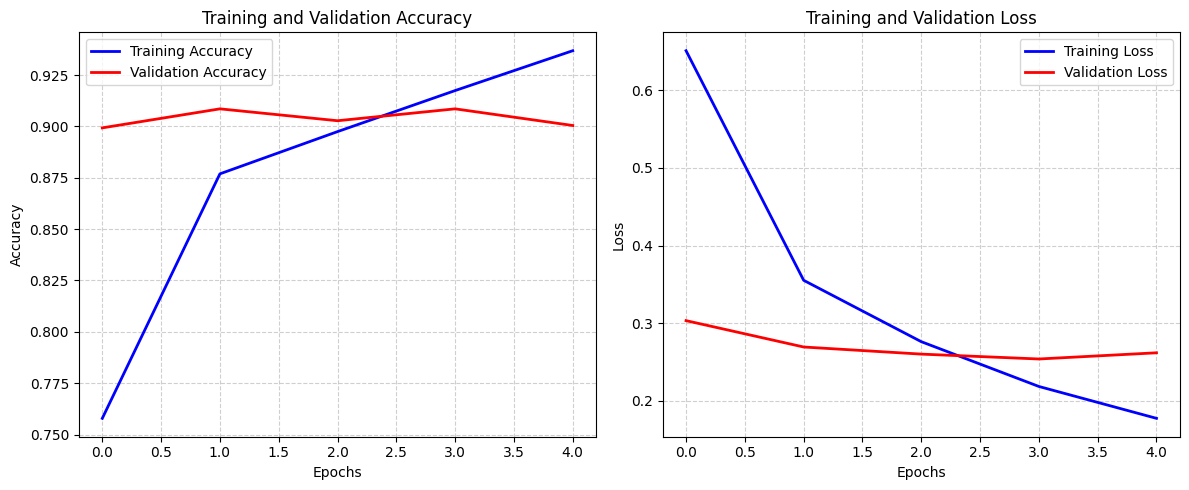

In [6]:
# Training History Visualization (Accuracy & Loss) 

# Accuracy grafic
plt.figure(figsize=(12, 5))

# 1. Accuracy grafic
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', lw=2)
plt.title('Training and Validation Accuracy', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Loss grafic
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', lw=2)
plt.title('Training and Validation Loss', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
'''import tensorflow as tf              bu kısım çalıştırılmayacak 
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(), # Katmanları dengelemek için
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'), # Katman sayısını biraz azalttık
    layers.Dropout(0.6), # Dropout oranını %50'den %60'a çıkardık
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) '''

In [ ]:
'''# Eğitim süresi (Epoch: Tüm verinin üzerinden kaç kez geçilecek)   burası da çalıştırılmayacak , bu iki kod kendi elimizle eğitirsek sonuç ne olurdu göstermek için 
# Başlangıç için 10-15 idealdir, duruma göre artırabiliriz
EPOCHS = 15
BATCH_SIZE = 32 # Aynı anda işlenecek görsel sayısı

history = model.fit(
    X_train, y_train,
    epochs=20, # Biraz daha uzun eğitebiliriz
    batch_size=32,
    validation_data=(X_test, y_test)
) '''

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


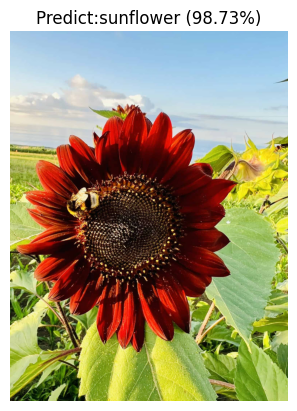

In [ ]:
def predict_flower(img_path):
    # 1. Load image and prepare for the model
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224)) # Model expects 224x224

    # 2. Normalization (Scaling to 0-1 range, as done during training)
    # The Lambda layer within the model will rescale this to [-1, 1]. 
    img_array = img_resized.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0) # (1, 224, 224, 3) Converts to (1, 224, 224, 3) format

    # 3.Make a prediction
    predictions = model.predict(img_array)
    class_idx = np.argmax(predictions) # Index of the class with the highest probability
    confidence = np.max(predictions) * 100 # Accuracy percentage

    # 4. Visualize the result
    plt.imshow(img)
    plt.title(f"Predict:{class_names[class_idx]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()


# Copy the path of the image you downloaded here
predict_flower('C:/Users/BEYZA/Desktop/papatya.webp')